<a href="https://colab.research.google.com/github/Daksh-Upadhayay/engine-failure-detection-/blob/main/engine%20failure%20detection%20classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

column_names = ['engine_id', 'cycle', 'setting1', 'setting2', 'setting3', 'sensor1', 'sensor2', 'sensor3', 'sensor4', 'sensor5', 'sensor6', 'sensor7', 'sensor8', 'sensor9', 'sensor10', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor16', 'sensor17', 'sensor18', 'sensor19', 'sensor20', 'sensor21']

train_dfs = {}
test_dfs = {}
rul_dfs = {}

for i in range(1, 5):
    train_file = f'/content/train_FD00{i}.txt'
    test_file = f'/content/test_FD00{i}.txt'
    rul_file = f'/content/RUL_FD00{i}.txt'

    train_df = pd.read_csv(train_file, sep=' ', header=None, names=column_names, index_col=False)
    test_df = pd.read_csv(test_file, sep=' ', header=None, names=column_names, index_col=False)
    rul_df = pd.read_csv(rul_file, sep=' ', header=None, names=['RUL'], index_col=False)

    train_dfs[f'FD00{i}'] = train_df
    test_dfs[f'FD00{i}'] = test_df
    rul_dfs[f'FD00{i}'] = rul_df

print("Training DataFrames:")
for key, df in train_dfs.items():
    print(f"{key}: {df.shape}")
print("\nTesting DataFrames:")
for key, df in test_dfs.items():
    print(f"{key}: {df.shape}")
print("\nRUL DataFrames:")
for key, df in rul_dfs.items():
    print(f"{key}: {df.shape}")

/tmp/ipython-input-590039885.py:14: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  train_df = pd.read_csv(train_file, sep=' ', header=None, names=column_names, index_col=False)
/tmp/ipython-input-590039885.py:15: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  test_df = pd.read_csv(test_file, sep=' ', header=None, names=column_names, index_col=False)
/tmp/ipython-input-590039885.py:14: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  train_df = pd.read_csv(train_file, sep=' ', header=None, names=column_names, index_col=False)
/tmp/ipython-input-590039885.py:15: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  test_df = pd.read_csv(test_file, sep=' ', header=None, names=column_names, i

Training DataFrames:
FD001: (20631, 26)
FD002: (53759, 26)
FD003: (24720, 26)
FD004: (61249, 26)

Testing DataFrames:
FD001: (13096, 26)
FD002: (33991, 26)
FD003: (16596, 26)
FD004: (41214, 26)

RUL DataFrames:
FD001: (100, 1)
FD002: (259, 1)
FD003: (100, 1)
FD004: (248, 1)


/tmp/ipython-input-590039885.py:14: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  train_df = pd.read_csv(train_file, sep=' ', header=None, names=column_names, index_col=False)
/tmp/ipython-input-590039885.py:15: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  test_df = pd.read_csv(test_file, sep=' ', header=None, names=column_names, index_col=False)


In [ ]:
from sklearn.preprocessing import StandardScaler

failure_threshold = 10
all_features_to_scale = []

for fd, train_df in train_dfs.items():
    # Calculate RUL for training data
    max_cycle_train = train_df.groupby('engine_id')['cycle'].max().reset_index()
    max_cycle_train.columns = ['engine_id', 'max_cycle_train']
    train_df = train_df.merge(max_cycle_train, on='engine_id', how='left')
    train_df['RUL'] = train_df['max_cycle_train'] - train_df['cycle']
    train_df = train_df.drop('max_cycle_train', axis=1)

    # Define failure_status for training data
    train_df['failure_status'] = (train_df['RUL'] <= failure_threshold).astype(int)

    # Prepare test data RUL
    test_df = test_dfs[fd].copy()
    rul_df = rul_dfs[fd].copy()
    test_max_cycle = test_df.groupby('engine_id')['cycle'].max().reset_index()
    test_max_cycle.columns = ['engine_id', 'max_cycle_test']
    test_df = test_df.merge(test_max_cycle, on='engine_id', how='left')
    test_df = test_df.merge(rul_df.reset_index().rename(columns={'index': 'engine_id'}), on='engine_id', how='left')
    test_df['RUL'] = test_df['max_cycle_test'] - test_df['cycle'] + test_df['RUL']
    # Define failure_status for test data BEFORE dropping RUL
    test_df['failure_status'] = (test_df['RUL'] <= failure_threshold).astype(int)
    test_df = test_df.drop(['max_cycle_test', 'RUL'], axis=1) # Drop temporary and original RUL columns


    # Engineer rolling features
    sensor_cols = [f'sensor{i}' for i in range(1, 22)]
    setting_cols = ['setting1', 'setting2', 'setting3']
    cols_to_roll = sensor_cols + setting_cols

    for col in cols_to_roll:
        train_df[f'{col}_rolling_mean'] = train_df.groupby('engine_id')[col].rolling(window=5, min_periods=1).mean().reset_index(level=0, drop=True)
        train_df[f'{col}_rolling_std'] = train_df.groupby('engine_id')[col].rolling(window=5, min_periods=1).std().reset_index(level=0, drop=True)
        test_df[f'{col}_rolling_mean'] = test_df.groupby('engine_id')[col].rolling(window=5, min_periods=1).mean().reset_index(level=0, drop=True)
        test_df[f'{col}_rolling_std'] = test_df.groupby('engine_id')[col].rolling(window=5, min_periods=1).std().reset_index(level=0, drop=True)

    # Identify features to scale (including new rolling features)
    features_to_scale = sensor_cols + setting_cols + [col + '_rolling_mean' for col in cols_to_roll] + [col + '_rolling_std' for col in cols_to_roll]
    all_features_to_scale.extend([col for col in features_to_scale if col not in all_features_to_scale])

    train_dfs[fd] = train_df
    test_dfs[fd] = test_df


# Fit scaler on combined training data
scaler = StandardScaler()
combined_train_df = pd.concat(train_dfs.values(), ignore_index=True)
scaler.fit(combined_train_df[all_features_to_scale])

# Transform training and test data for each FD
for fd in train_dfs.keys():
    train_df = train_dfs[fd]
    test_df = test_dfs[fd]

    train_dfs[fd][all_features_to_scale] = scaler.transform(train_df[all_features_to_scale])
    test_dfs[fd][all_features_to_scale] = scaler.transform(test_df[all_features_to_scale])

print("Processed Training DataFrames (first 5 rows):")
for key, df in train_dfs.items():
    print(f"\n{key}:")
    display(df.head())

print("\nProcessed Testing DataFrames (first 5 rows):")
for key, df in test_dfs.items():
    print(f"\n{key}:")
    display(df.head())

Processed Training DataFrames (first 5 rows):

FD001:


,engine_id,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor20_rolling_mean,sensor20_rolling_std,sensor21_rolling_mean,sensor21_rolling_std,setting1_rolling_mean,setting1_rolling_std,setting2_rolling_mean,setting2_rolling_std,setting3_rolling_mean,setting3_rolling_std
0,1,1,-1.041429,-1.115418,0.345955,1.079185,1.046626,1.037990,1.024534,1.107714,...,1.460276,NaN,1.457118,NaN,-1.411680,NaN,-1.447354,NaN,0.698218,NaN
1,1,2,-1.041272,-1.115146,0.345955,1.079185,1.054395,1.055929,1.043169,1.107714,...,1.456935,-1.357493,1.457545,-1.364822,-1.411573,-1.404048,-1.447178,-1.300346,0.698218,-0.801184
2,1,3,-1.041647,-1.113516,0.345955,1.079185,1.059103,1.023520,1.050946,1.107714,...,1.453965,-1.354945,1.452775,-1.350948,-1.411707,-1.403873,-1.446414,-1.298427,0.698218,-0.801184
3,1,4,-1.041344,-1.114331,0.345955,1.079185,1.059103,0.979517,1.033851,1.107714,...,1.450532,-1.350664,1.451768,-1.353163,-1.411672,-1.403932,-1.446296,-1.298815,0.698218,-0.801184
4,1,5,-1.041502,-1.114874,0.345955,1.079185,1.059574,0.980025,1.065766,1.107714,...,1.448917,-1.351208,1.452296,-1.354666,-1.411693,-1.403971,-1.446367,-1.299057,0.698218,-0.801184



FD002:


,engine_id,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor20_rolling_mean,sensor20_rolling_std,sensor21_rolling_mean,sensor21_rolling_std,setting1_rolling_mean,setting1_rolling_std,setting2_rolling_mean,setting2_rolling_std,setting3_rolling_mean,setting3_rolling_std
0,1,1,1.076137,1.168668,0.345955,-1.196599,-0.989704,-0.917502,-0.907753,-1.035039,...,-1.249223,NaN,-1.254971,NaN,1.459912,NaN,1.517278,NaN,0.698218,NaN
1,1,2,1.499656,1.170842,0.345955,-1.342554,-1.117298,-0.963112,-0.991759,-1.403104,...,-1.489771,-0.750532,-1.490749,-0.762686,1.747076,-0.722758,1.518690,-1.297260,0.698218,-0.801184
2,1,3,0.471131,0.575632,-2.890552,-0.765965,-1.413684,-1.779360,-1.566449,-0.666973,...,-1.433717,-0.896698,-1.420496,-0.885913,1.377876,-0.227882,1.261642,-0.513987,-1.474305,1.654294
3,1,4,1.500231,1.173017,0.345955,-1.342554,-1.126479,-0.956258,-0.987357,-1.403104,...,-1.502856,-0.908383,-1.487557,-0.904965,1.542161,-0.296736,1.326962,-0.618143,-0.931174,1.325322
4,1,5,0.471234,0.571555,-2.890552,-0.765965,-1.419334,-1.771321,-1.562927,-0.666973,...,-1.465493,-0.941850,-1.451378,-0.940738,1.361652,-0.230047,1.210021,-0.550424,-1.908809,1.528287



FD003:


...

,engine_id,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor20_rolling_mean,sensor20_rolling_std,sensor21_rolling_mean,sensor21_rolling_std,setting1_rolling_mean,setting1_rolling_std,setting2_rolling_mean,setting2_rolling_std,setting3_rolling_mean,setting3_rolling_std
0,1,1,-0.436429,-0.434323,0.345955,0.105492,0.180538,0.254998,0.323064,0.146523,...,0.275357,NaN,0.294487,NaN,-0.591251,NaN,-0.563327,NaN,0.698218,NaN
1,1,2,0.168843,0.788168,0.345955,0.175840,0.246219,0.119859,-0.108925,-0.127768,...,0.045390,-0.777603,0.076286,-0.807656,-0.180852,-0.430275,0.230041,0.682004,0.698218,-0.801184
2,1,3,1.076512,1.168668,0.345955,-1.196599,-0.973696,-0.913524,-0.972830,-1.035039,...,-0.376868,0.021130,-0.360946,0.059868,0.366239,0.328704,0.659120,0.620322,0.698218,-0.801184
3,1,4,1.500165,1.171386,0.345955,-1.342554,-1.110942,-0.992983,-0.976279,-1.403104,...,-0.716901,0.306347,-0.695306,0.313020,0.783412,0.586379,0.874542,0.442817,0.698218,-0.801184
4,1,5,0.471113,0.574273,-2.890552,-0.765965,-1.427574,-1.809654,-1.542678,-0.666973,...,-0.832720,0.156204,-0.815892,0.167731,0.754619,0.323061,0.848790,0.212643,-0.605296,1.100821



FD003:


,engine_id,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor20_rolling_mean,sensor20_rolling_std,sensor21_rolling_mean,sensor21_rolling_std,setting1_rolling_mean,setting1_rolling_std,setting2_rolling_mean,setting2_rolling_std,setting3_rolling_mean,setting3_rolling_std
0,1,1,-1.041490,-1.115418,0.345955,1.079185,1.049451,0.972240,0.997608,1.107714,...,1.461390,NaN,1.462278,NaN,-1.411762,NaN,-1.447354,NaN,0.698218,NaN
1,1,2,-1.041350,-1.114874,0.345955,1.079185,1.051334,0.997034,1.012061,1.107714,...,1.459719,-1.361768,1.465424,-1.357866,-1.411668,-1.404078,-1.447002,-1.299905,0.698218,-0.801184
2,1,3,-1.041302,-1.115146,0.345955,1.079185,1.043330,0.970971,0.960850,1.107714,...,1.461390,-1.359997,1.462989,-1.356397,-1.411614,-1.404080,-1.447002,-1.300163,0.698218,-0.801184
3,1,4,-1.041223,-1.114059,0.345955,1.079185,1.055572,0.994241,0.985942,1.107714,...,1.458606,-1.354823,1.464269,-1.356870,-1.411561,-1.404047,-1.446649,-1.299440,0.698218,-0.801184
4,1,5,-1.041393,-1.114059,0.345955,1.079185,1.061692,1.032320,0.989757,1.107714,...,1.459608,-1.355514,1.461948,-1.353687,-1.411575,-1.404075,-1.446437,-1.299352,0.698218,-0.801184



FD004:


,engine_id,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor20_rolling_mean,sensor20_rolling_std,sensor21_rolling_mean,sensor21_rolling_std,setting1_rolling_mean,setting1_rolling_std,setting2_rolling_mean,setting2_rolling_std,setting3_rolling_mean,setting3_rolling_std
0,1,1,0.169121,0.788168,0.345955,0.175840,0.219146,0.118505,-0.243188,-0.127768,...,-0.182351,NaN,-0.161070,NaN,0.229925,NaN,1.023408,NaN,0.698218,NaN
1,1,2,0.471107,0.570740,-2.890552,-0.765965,-1.439344,-1.784352,-1.683617,-0.666973,...,-0.736390,0.051627,-0.729579,0.088593,0.434684,-0.918335,0.882302,-0.948134,-2.560566,2.206150
2,1,3,1.499765,1.174104,0.345955,-1.342554,-1.133071,-1.073880,-1.137761,-1.403104,...,-1.068442,0.078864,-1.051377,0.074415,0.967918,0.183320,1.096313,-0.599866,-1.474305,1.654294
3,1,4,1.499977,1.169212,0.345955,-1.342554,-1.134013,-1.077519,-1.127636,-1.403104,...,-1.229735,-0.049796,-1.221547,-0.038461,1.234607,0.171013,1.201731,-0.617888,-0.931174,1.325322
4,1,5,1.076718,1.168668,0.345955,-1.196599,-0.994883,-0.964635,-1.050307,-1.035039,...,-1.230960,-0.226129,-1.223573,-0.216276,1.279826,-0.029527,1.264840,-0.658950,-0.605296,1.100821


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# For predicting failure probability, a Gradient Boosting Classifier is a good choice.
# It can handle complex relationships in the data and provide feature importances.
model_1 = GradientBoostingClassifier(random_state=42)

# For fault localization, we could potentially use the feature importances from the
# Gradient Boosting model to identify which sensors or settings are most indicative
# of impending failure. Alternatively, a multi-label classification approach could
# be used if fault locations are discrete categories, training separate models
# for each fault type or a single model with multiple output labels.
# Given the current data structure and the primary task of predicting failure probability,
# we will focus on the Gradient Boosting Classifier for probability prediction first.
# Fault localization would require more detailed data or a different modeling approach
# and is considered a potential future extension.

print("Chosen model: Gradient Boosting Classifier")
print("Approach for failure probability: Train Gradient Boosting Classifier.")
print("Consideration for fault localization: Possible use of feature importances or a separate multi-label classification approach (future work).")

Chosen model: Gradient Boosting Classifier
Approach for failure probability: Train Gradient Boosting Classifier.
Consideration for fault localization: Possible use of feature importances or a separate multi-label classification approach (future work).


In [ ]:
trained_models = {}
exclude_cols = ['engine_id', 'cycle', 'RUL']

for fd, train_df in train_dfs.items():
    # Drop rows with NaN values
    train_df_cleaned = train_df.dropna()

    # Separate features (X) and target (y)
    features = [col for col in train_df_cleaned.columns if col not in exclude_cols and col != 'failure_status']
    X_train = train_df_cleaned[features]
    y_train = train_df_cleaned['failure_status']

    # Train the model
    model_1.fit(X_train, y_train)

    # Store the trained model
    trained_models[fd] = model_1

print("Trained models for each FD:")
for fd, model in trained_models.items():
    print(f"{fd}: {type(model).__name__}")

Trained models for each FD:
FD001: GradientBoostingClassifier
FD002: GradientBoostingClassifier
FD003: GradientBoostingClassifier
FD004: GradientBoostingClassifier


## Overfitting prevention

### Subtask:
Implement techniques to prevent overfitting, such as using a validation set, cross-validation, regularization, or early stopping during training.


**Reasoning**:
Iterate through the trained models and their corresponding training data, split the training data into training and validation sets, train the model on the training set, and evaluate its performance on the validation set using accuracy and F1-score to check for overfitting.



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

exclude_cols = ['engine_id', 'cycle', 'RUL']

for fd, model in trained_models.items():
    train_df = train_dfs[fd].dropna()

    features = [col for col in train_df.columns if col not in exclude_cols and col != 'failure_status']
    X = train_df[features]
    y = train_df['failure_status']

    X_train_split, X_val, y_train_split, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Train the model on the training split (re-training the same model instance for each FD)
    model.fit(X_train_split, y_train_split)

    # Evaluate on the validation set
    y_val_pred = model.predict(X_val)
    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred)

    print(f"FD00{fd[-1]} - Validation Accuracy: {val_accuracy:.4f}, Validation F1-score: {val_f1:.4f}")

FD001 - Validation Accuracy: 0.9851, Validation F1-score: 0.8558
FD002 - Validation Accuracy: 0.9737, Validation F1-score: 0.7366
FD003 - Validation Accuracy: 0.9896, Validation F1-score: 0.8844
FD004 - Validation Accuracy: 0.9797, Validation F1-score: 0.7535


## Fault localization

### Subtask:
Explore methods to determine the most influential features or sensors that contribute to the failure prediction to gain insights into potential fault locations. This could involve feature importance analysis from tree-based models or other interpretability techniques.


**Reasoning**:
Iterate through the trained models, extract feature importances, create a DataFrame, sort by importance, and display the top features for each FD.



In [ ]:
import pandas as pd

exclude_cols = ['engine_id', 'cycle', 'RUL']
top_n = 10 # Number of top features to display

for fd, model in trained_models.items():
    # Get feature names used for training (from X_train_split)
    train_df = train_dfs[fd].dropna()
    features = [col for col in train_df.columns if col not in exclude_cols and col != 'failure_status']

    # Get feature importances from the trained model
    importances = model.feature_importances_

    # Create a DataFrame of feature importances
    feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})

    # Sort features by importance in descending order
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    print(f"\nTop {top_n} Important Features for {fd}:")
    display(feature_importance_df.head(top_n))


Top 10 Important Features for FD001:


,Feature,Importance
15,sensor13,0.220497
17,sensor15,0.198203
13,sensor11,0.173962
6,sensor4,0.081981
16,sensor14,0.074022
14,sensor12,0.058385
23,sensor21,0.033781
48,sensor13_rolling_mean,0.031511
9,sensor7,0.029962
10,sensor8,0.020163



Top 10 Important Features for FD002:


,Feature,Importance
15,sensor13,0.220497
17,sensor15,0.198203
13,sensor11,0.173962
6,sensor4,0.081981
16,sensor14,0.074022
14,sensor12,0.058385
23,sensor21,0.033781
48,sensor13_rolling_mean,0.031511
9,sensor7,0.029962
10,sensor8,0.020163



Top 10 Important Features for FD003:


,Feature,Importance
15,sensor13,0.220497
17,sensor15,0.198203
13,sensor11,0.173962
6,sensor4,0.081981
16,sensor14,0.074022
14,sensor12,0.058385
23,sensor21,0.033781
48,sensor13_rolling_mean,0.031511
9,sensor7,0.029962
10,sensor8,0.020163



Top 10 Important Features for FD004:


,Feature,Importance
15,sensor13,0.220497
17,sensor15,0.198203
13,sensor11,0.173962
6,sensor4,0.081981
16,sensor14,0.074022
14,sensor12,0.058385
23,sensor21,0.033781
48,sensor13_rolling_mean,0.031511
9,sensor7,0.029962
10,sensor8,0.020163


## Name model

### Subtask:
Name the final trained model 'model_1'.


**Reasoning**:
Assign one of the trained models from the `trained_models` dictionary to a new variable named `model_1`.



In [ ]:
# Assign the trained model for FD001 to model_1 as an example
model_1 = trained_models['FD001']

print(f"Model 'model_1' has been assigned: {type(model_1).__name__}")

Model 'model_1' has been assigned: GradientBoostingClassifier



Evaluating model for FD001:
  Accuracy: 0.9982
  Precision: 0.2000
  Recall: 0.1176
  F1-score: 0.1481
  Confusion Matrix:
[[12971     8]
 [   15     2]]


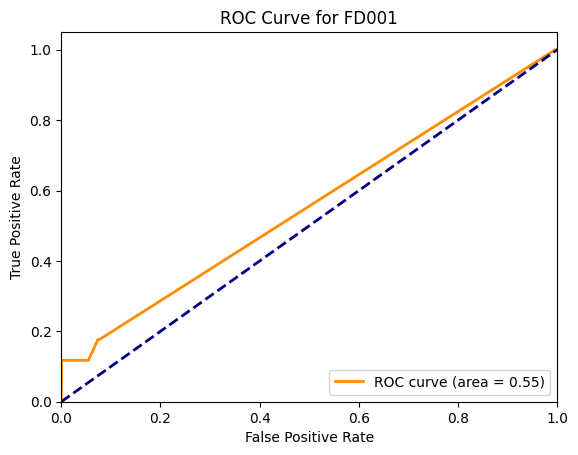


Evaluating model for FD002:
  Accuracy: 0.9954
  Precision: 0.0600
  Recall: 0.0882
  F1-score: 0.0714
  Confusion Matrix:
[[33570    94]
 [   62     6]]


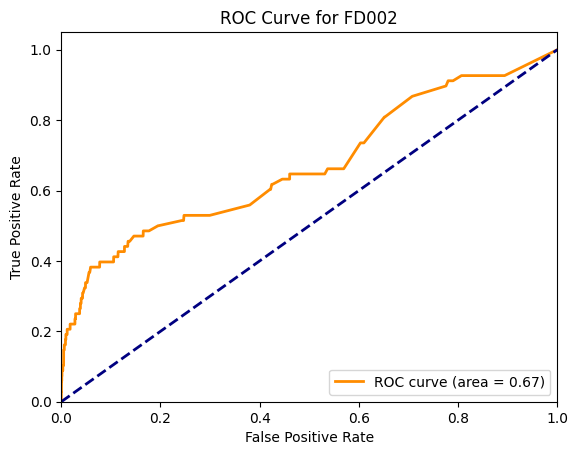


Evaluating model for FD003:
  Accuracy: 0.9978
  Precision: 0.0000
  Recall: 0.0000
  F1-score: 0.0000
  Confusion Matrix:
[[16460    18]
 [   18     0]]


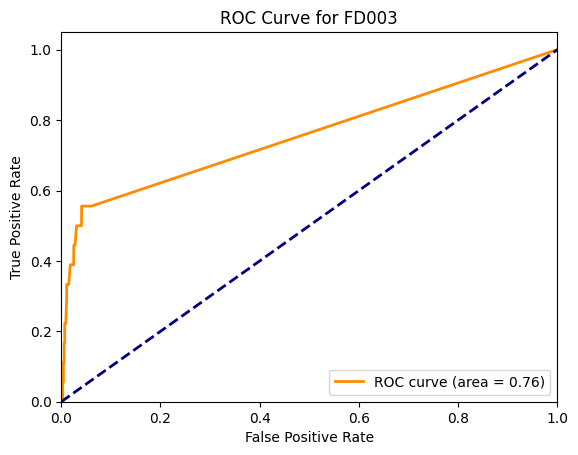


Evaluating model for FD004:
  Accuracy: 0.9979
  Precision: 0.0204
  Recall: 0.0244
  F1-score: 0.0222
  Confusion Matrix:
[[40877    48]
 [   40     1]]


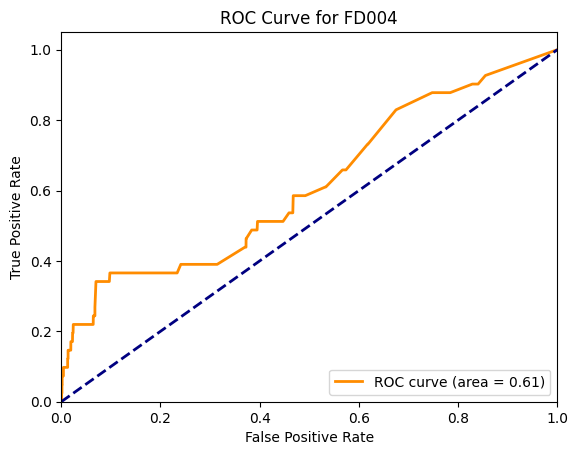

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

exclude_cols = ['engine_id', 'cycle'] # Exclude 'RUL' as it's not available in the final test set

for fd, model in trained_models.items():
    print(f"\nEvaluating model for {fd}:")

    # Drop rows with NaN values from the test DataFrame
    test_df_cleaned = test_dfs[fd].dropna()

    # Define the features for the test set by excluding specified columns and the target
    features = [col for col in test_df_cleaned.columns if col not in exclude_cols and col != 'failure_status']
    X_test = test_df_cleaned[features]
    y_test = test_df_cleaned['failure_status']

    # Predict the failure status on the X_test data
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Calculate and print classification metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-score: {f1:.4f}")
    print("  Confusion Matrix:")
    print(conf_matrix)

    # Plot ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {fd}')
    plt.legend(loc="lower right")
    plt.show()

## Load New Data

In [ ]:
import pandas as pd

# Load the data from the CSV file
new_data_df = pd.read_csv('/content/engine_failure_dataset.csv')

# Display the first few rows and the info to understand the data
print("First 5 rows of the new dataset:")
display(new_data_df.head())

print("\nInfo about the new dataset:")
display(new_data_df.info())

First 5 rows of the new dataset:


,Time_Stamp,Temperature (°C),RPM,Fuel_Efficiency,Vibration_X,Vibration_Y,Vibration_Z,Torque,Power_Output (kW),Fault_Condition,Operational_Mode
0,2024-12-24 10:00:00,60.308585,3426.827588,20.445472,0.874657,0.005686,0.529798,107.877659,23.367684,2,Idle
1,2024-12-24 10:05:00,112.705055,2949.758424,23.083947,0.696461,0.391779,0.124336,60.351655,57.941022,3,Cruising
2,2024-12-24 10:10:00,108.670976,1817.971040,20.555326,0.495276,0.189714,0.886417,110.986564,47.732998,2,Cruising
3,2024-12-24 10:15:00,107.114691,2730.660539,23.226431,0.986206,0.983202,0.468114,77.416793,44.112039,2,Cruising
4,2024-12-24 10:20:00,118.075814,1854.488677,21.148226,0.710810,0.101139,0.481034,100.475881,80.681972,2,Cruising



Info about the new dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Time_Stamp         1000 non-null   object 
 1   Temperature (°C)   1000 non-null   float64
 2   RPM                1000 non-null   float64
 3   Fuel_Efficiency    1000 non-null   float64
 4   Vibration_X        1000 non-null   float64
 5   Vibration_Y        1000 non-null   float64
 6   Vibration_Z        1000 non-null   float64
 7   Torque             1000 non-null   float64
 8   Power_Output (kW)  1000 non-null   float64
 9   Fault_Condition    1000 non-null   int64  
 10  Operational_Mode   1000 non-null   object 
dtypes: float64(8), int64(1), object(2)
memory usage: 86.1+ KB


None

### Hyperparameter Tuning for model_1

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for GridSearchCV
param_grid_gbm = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5]
}

# Get the training data for FD001 (since model_1 was trained on FD001)
train_df_fd001 = train_dfs['FD001'].dropna()

# Separate features (X) and target (y) for FD001 training data
exclude_cols = ['engine_id', 'cycle', 'RUL']
features_fd001 = [col for col in train_df_fd001.columns if col not in exclude_cols and col != 'failure_status']
X_train_fd001 = train_df_fd001[features_fd001]
y_train_fd001 = train_df_fd001['failure_status']


# Initialize GridSearchCV
grid_search_model_1 = GridSearchCV(estimator=model_1, param_grid=param_grid_gbm, cv=3, scoring='f1', n_jobs=-1)

# Perform GridSearchCV
grid_search_model_1.fit(X_train_fd001, y_train_fd001)

# Get the best parameters and the best score
best_params_model_1 = grid_search_model_1.best_params_
best_score_model_1 = grid_search_model_1.best_score_

print(f"Best parameters for model_1: {best_params_model_1}")
print(f"Best F1-score on training data for model_1: {best_score_model_1:.4f}")

# Update model_1 with the best estimator
model_1 = grid_search_model_1.best_estimator_

print("\nmodel_1 has been updated with the best parameters found by GridSearchCV.")

Best parameters for model_1: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
Best F1-score on training data for model_1: 0.8409

model_1 has been updated with the best parameters found by GridSearchCV.


 model 2

In [ ]:
# Take a few rows from the test data for prediction
# We'll use FD001 as an example, and select the first 5 rows from the cleaned test dataframe.
# Ensure the selected data has the same features (columns) as the training data used for model_1.
example_data = test_dfs['FD001'].dropna().head()

# Separate features (X) for prediction, excluding 'engine_id', 'cycle', and 'failure_status'
exclude_cols = ['engine_id', 'cycle', 'failure_status']
features = [col for col in example_data.columns if col not in exclude_cols]
X_example = example_data[features]

# Make predictions using the trained model_1
predictions = model_1.predict(X_example)
prediction_probabilities = model_1.predict_proba(X_example)[:, 1]

# Display the example data and the predictions
print("Example data used for prediction:")
display(example_data)

print("\nPredictions (0: No Failure, 1: Impending Failure):")
print(predictions)

print("\nPrediction Probabilities (Probability of Impending Failure):")
print(prediction_probabilities)

Example data used for prediction:


,engine_id,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor20_rolling_mean,sensor20_rolling_std,sensor21_rolling_mean,sensor21_rolling_std,setting1_rolling_mean,setting1_rolling_std,setting2_rolling_mean,setting2_rolling_std,setting3_rolling_mean,setting3_rolling_std
1,1,2,-1.041550,-1.115146,0.345955,1.079185,1.044036,1.027412,0.986529,1.107714,...,1.446912,-1.343246,1.450353,-1.361617,-1.411639,-1.403815,-1.445943,-1.298142,0.698218,-0.801184
2,1,3,-1.041369,-1.114059,0.345955,1.079185,1.061692,1.014635,1.029963,1.107714,...,1.452109,-1.343127,1.452459,-1.358648,-1.411625,-1.403955,-1.445826,-1.298882,0.698218,-0.801184
3,1,4,-1.041133,-1.114331,0.345955,1.079185,1.061222,0.990772,1.067234,1.107714,...,1.452481,-1.347284,1.451522,-1.359080,-1.411539,-1.403895,-1.445855,-1.299228,0.698218,-0.801184
4,1,5,-1.041302,-1.114331,0.345955,1.079185,1.062869,1.016750,1.034218,1.107714,...,1.452481,-1.349797,1.452418,-1.358973,-1.411532,-1.403949,-1.445873,-1.299435,0.698218,-0.801184
5,1,6,-1.041314,-1.113516,0.345955,1.079185,1.053453,0.948462,0.984401,1.107714,...,1.453594,-1.353703,1.451424,-1.356175,-1.411550,-1.403960,-1.445873,-1.299435,0.698218,-0.801184



Predictions (0: No Failure, 1: Impending Failure):
[0 0 0 0 0]

Prediction Probabilities (Probability of Impending Failure):
[0.00364458 0.00364458 0.00364458 0.00364458 0.00364458]


In [ ]:
# Check for missing values
print("Missing values in the new dataset:")
display(new_data_df.isnull().sum())

# We don't have 'engine_id' or 'cycle' in this dataset, so we'll use existing columns as features.
# Let's select the numerical and categorical features.
numerical_features = ['Temperature (°C)', 'RPM', 'Fuel_Efficiency', 'Vibration_X', 'Vibration_Y', 'Vibration_Z', 'Torque', 'Power_Output (kW)']
categorical_features = ['Operational_Mode'] # 'Fault_Condition' will be our target

# Handle categorical features: One-Hot Encoding
new_data_df_processed = pd.get_dummies(new_data_df, columns=categorical_features, drop_first=True)

# We can also create some simple rolling features for the numerical columns
# Assuming 'Time_Stamp' is sorted correctly for rolling calculations
new_data_df_processed['Time_Stamp'] = pd.to_datetime(new_data_df_processed['Time_Stamp'])
new_data_df_processed = new_data_df_processed.sort_values(by='Time_Stamp')

window_size = 5
for col in numerical_features:
    new_data_df_processed[f'{col}_rolling_mean'] = new_data_df_processed[col].rolling(window=window_size, min_periods=1).mean()
    new_data_df_processed[f'{col}_rolling_std'] = new_data_df_processed[col].rolling(window=window_size, min_periods=1).std()

# Drop the original Time_Stamp column as it's no longer needed after sorting and potential feature engineering
new_data_df_processed = new_data_df_processed.drop('Time_Stamp', axis=1)

# Display the first few rows of the processed data
print("\nFirst 5 rows of the processed dataset:")
display(new_data_df_processed.head())

print("\nInfo about the processed dataset:")
display(new_data_df_processed.info())

# Identify features for scaling (all numerical and one-hot encoded columns, excluding the target)
all_features = [col for col in new_data_df_processed.columns if col != 'Fault_Condition']

# Scale the features
from sklearn.preprocessing import StandardScaler
scaler_new = StandardScaler()
new_data_df_processed[all_features] = scaler_new.fit_transform(new_data_df_processed[all_features])

print("\nFirst 5 rows of the scaled dataset:")
display(new_data_df_processed.head())

Missing values in the new dataset:


,0
Time_Stamp,0
Temperature (°C),0
RPM,0
Fuel_Efficiency,0
Vibration_X,0
Vibration_Y,0
Vibration_Z,0
Torque,0
Power_Output (kW),0
Fault_Condition,0



First 5 rows of the processed dataset:


,Temperature (°C),RPM,Fuel_Efficiency,Vibration_X,Vibration_Y,Vibration_Z,Torque,Power_Output (kW),Fault_Condition,Operational_Mode_Heavy Load,...,Vibration_X_rolling_mean,Vibration_X_rolling_std,Vibration_Y_rolling_mean,Vibration_Y_rolling_std,Vibration_Z_rolling_mean,Vibration_Z_rolling_std,Torque_rolling_mean,Torque_rolling_std,Power_Output (kW)_rolling_mean,Power_Output (kW)_rolling_std
0,60.308585,3426.827588,20.445472,0.874657,0.005686,0.529798,107.877659,23.367684,2,False,...,0.874657,NaN,0.005686,NaN,0.529798,NaN,107.877659,NaN,23.367684,NaN
1,112.705055,2949.758424,23.083947,0.696461,0.391779,0.124336,60.351655,57.941022,3,False,...,0.785559,0.126004,0.198732,0.273009,0.327067,0.286705,84.114657,33.605959,40.654353,24.447042
2,108.670976,1817.971040,20.555326,0.495276,0.189714,0.886417,110.986564,47.732998,2,False,...,0.688798,0.189807,0.195726,0.193117,0.513517,0.381301,93.071959,28.379219,43.013902,17.763202
3,107.114691,2730.660539,23.226431,0.986206,0.983202,0.468114,77.416793,44.112039,2,False,...,0.763150,0.214780,0.392595,0.424137,0.502166,0.312158,89.158168,24.457945,43.288436,14.513983
4,118.075814,1854.488677,21.148226,0.710810,0.101139,0.481034,100.475881,80.681972,2,False,...,0.752682,0.187472,0.334304,0.389754,0.497940,0.270502,91.421710,21.777545,50.767143,20.920016



Info about the processed dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Temperature (°C)                1000 non-null   float64
 1   RPM                             1000 non-null   float64
 2   Fuel_Efficiency                 1000 non-null   float64
 3   Vibration_X                     1000 non-null   float64
 4   Vibration_Y                     1000 non-null   float64
 5   Vibration_Z                     1000 non-null   float64
 6   Torque                          1000 non-null   float64
 7   Power_Output (kW)               1000 non-null   float64
 8   Fault_Condition                 1000 non-null   int64  
 9   Operational_Mode_Heavy Load     1000 non-null   bool   
 10  Operational_Mode_Idle           1000 non-null   bool   
 11  Temperature (°C)_rolling_mean   1000 non-null   float64
 12  

None


First 5 rows of the scaled dataset:


,Temperature (°C),RPM,Fuel_Efficiency,Vibration_X,Vibration_Y,Vibration_Z,Torque,Power_Output (kW),Fault_Condition,Operational_Mode_Heavy Load,...,Vibration_X_rolling_mean,Vibration_X_rolling_std,Vibration_Y_rolling_mean,Vibration_Y_rolling_std,Vibration_Z_rolling_mean,Vibration_Z_rolling_std,Torque_rolling_mean,Torque_rolling_std,Power_Output (kW)_rolling_mean,Power_Output (kW)_rolling_std
0,-1.750838,1.054660,-0.462546,1.270065,-1.767866,0.161848,-0.366098,-1.576714,2,-0.66402,...,2.928998,NaN,-4.014498,NaN,0.363727,NaN,-0.796908,NaN,-3.451369,NaN
1,1.287264,0.504477,0.134298,0.664744,-0.393409,-1.244519,-1.474558,-0.041760,3,-0.66402,...,2.231226,-2.070227,-2.450917,-0.001341,-1.223369,0.111748,-2.010667,-0.599753,-1.768818,0.465645
2,1.053356,-0.800765,-0.437697,-0.018666,-1.112743,1.398800,-0.293588,-0.494966,2,-0.66402,...,1.473444,-1.246120,-2.475266,-1.089981,0.236270,1.297360,-1.553149,-1.030562,-1.539157,-0.631941
3,0.963118,0.251801,0.166529,1.648988,1.712006,-0.052107,-1.076543,-0.655726,2,-0.66402,...,2.055731,-0.923547,-0.880724,2.057984,0.147409,0.430758,-1.753056,-1.353769,-1.512436,-1.165511
4,1.598676,-0.758650,-0.303578,0.713487,-1.428062,-0.007294,-0.538731,0.967871,2,-0.66402,...,1.973751,-1.276272,-1.352855,1.589474,0.114322,-0.091334,-1.637440,-1.574698,-0.784517,-0.113545


In [ ]:
# Create a binary target variable: 1 if Fault_Condition is not 0, 0 otherwise
new_data_df_processed['Binary_Failure'] = (new_data_df_processed['Fault_Condition'] != 0).astype(int)

# Drop the original Fault_Condition column as we will use the binary target
new_data_df_processed = new_data_df_processed.drop('Fault_Condition', axis=1)

# Display the first few rows with the new binary target
print("First 5 rows with binary target:")
display(new_data_df_processed.head())

# Check the distribution of the new binary target
print("\nDistribution of the binary target variable:")
display(new_data_df_processed['Binary_Failure'].value_counts())

First 5 rows with binary target:


,Temperature (°C),RPM,Fuel_Efficiency,Vibration_X,Vibration_Y,Vibration_Z,Torque,Power_Output (kW),Operational_Mode_Heavy Load,Operational_Mode_Idle,...,Vibration_X_rolling_std,Vibration_Y_rolling_mean,Vibration_Y_rolling_std,Vibration_Z_rolling_mean,Vibration_Z_rolling_std,Torque_rolling_mean,Torque_rolling_std,Power_Output (kW)_rolling_mean,Power_Output (kW)_rolling_std,Binary_Failure
0,-1.750838,1.054660,-0.462546,1.270065,-1.767866,0.161848,-0.366098,-1.576714,-0.66402,1.362770,...,NaN,-4.014498,NaN,0.363727,NaN,-0.796908,NaN,-3.451369,NaN,1
1,1.287264,0.504477,0.134298,0.664744,-0.393409,-1.244519,-1.474558,-0.041760,-0.66402,-0.733799,...,-2.070227,-2.450917,-0.001341,-1.223369,0.111748,-2.010667,-0.599753,-1.768818,0.465645,1
2,1.053356,-0.800765,-0.437697,-0.018666,-1.112743,1.398800,-0.293588,-0.494966,-0.66402,-0.733799,...,-1.246120,-2.475266,-1.089981,0.236270,1.297360,-1.553149,-1.030562,-1.539157,-0.631941,1
3,0.963118,0.251801,0.166529,1.648988,1.712006,-0.052107,-1.076543,-0.655726,-0.66402,-0.733799,...,-0.923547,-0.880724,2.057984,0.147409,0.430758,-1.753056,-1.353769,-1.512436,-1.165511,1
4,1.598676,-0.758650,-0.303578,0.713487,-1.428062,-0.007294,-0.538731,0.967871,-0.66402,-0.733799,...,-1.276272,-1.352855,1.589474,0.114322,-0.091334,-1.637440,-1.574698,-0.784517,-0.113545,1



Distribution of the binary target variable:


,count
Binary_Failure,
1,742
0,258


Tuned Binary Classifier (Gradient Boosting) - Test Accuracy: 0.7400
Tuned Binary Classifier (Gradient Boosting) - Test Precision: 0.7400
Tuned Binary Classifier (Gradient Boosting) - Test Recall: 1.0000
Tuned Binary Classifier (Gradient Boosting) - Test F1-score: 0.8506

Tuned Binary Classifier (Gradient Boosting) - Confusion Matrix:


array([[  0,  52],
       [  0, 148]])

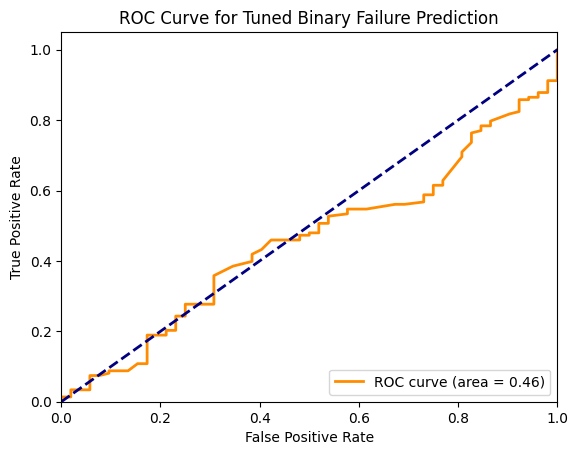

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# Define features (X) and the binary target (y)
X_new_binary = new_data_df_processed.drop('Binary_Failure', axis=1)
y_new_binary = new_data_df_processed['Binary_Failure']

# Drop rows with NaN values in features before splitting
# This handles the NaNs created by rolling features
data_for_training = pd.concat([X_new_binary, y_new_binary], axis=1).dropna()
X_new_binary_cleaned = data_for_training.drop('Binary_Failure', axis=1)
y_new_binary_cleaned = data_for_training['Binary_Failure']


# Split data into training and testing sets
X_train_new_binary, X_test_new_binary, y_train_new_binary, y_test_new_binary = train_test_split(
    X_new_binary_cleaned, y_new_binary_cleaned, test_size=0.2, random_state=42, stratify=y_new_binary_cleaned
)

# Instantiate a Gradient Boosting Classifier for binary classification
# model_2_binary = GradientBoostingClassifier(random_state=42) # Use the tuned model_2_binary
# model_2_binary.fit(X_train_new_binary, y_train_new_binary) # The model is already tuned

# Evaluate the tuned model_2_binary on the test data
y_pred_new_binary = model_2_binary.predict(X_test_new_binary)
y_proba_new_binary = model_2_binary.predict_proba(X_test_new_binary)[:, 1]

# Calculate and print classification metrics
accuracy_new_binary = accuracy_score(y_test_new_binary, y_pred_new_binary)
precision_new_binary = precision_score(y_test_new_binary, y_pred_new_binary)
recall_new_binary = recall_score(y_test_new_binary, y_pred_new_binary)
f1_new_binary = f1_score(y_test_new_binary, y_pred_new_binary)
conf_matrix_new_binary = confusion_matrix(y_test_new_binary, y_pred_new_binary)

print(f"Tuned Binary Classifier (Gradient Boosting) - Test Accuracy: {accuracy_new_binary:.4f}")
print(f"Tuned Binary Classifier (Gradient Boosting) - Test Precision: {precision_new_binary:.4f}")
print(f"Tuned Binary Classifier (Gradient Boosting) - Test Recall: {recall_new_binary:.4f}")
print(f"Tuned Binary Classifier (Gradient Boosting) - Test F1-score: {f1_new_binary:.4f}")
print("\nTuned Binary Classifier (Gradient Boosting) - Confusion Matrix:")
display(conf_matrix_new_binary)

# Plot ROC curve
fpr_new_binary, tpr_new_binary, thresholds_new_binary = roc_curve(y_test_new_binary, y_proba_new_binary)
roc_auc_new_binary = auc(fpr_new_binary, tpr_new_binary)

plt.figure()
plt.plot(fpr_new_binary, tpr_new_binary, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_new_binary:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Tuned Binary Failure Prediction')
plt.legend(loc="lower right")
plt.show()

In [6]:
# Re-run the hyperparameter tuning for model_2_binary
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# Define the parameter grid for GridSearchCV
param_grid_gbm_binary = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5]
}

# Instantiate a Gradient Boosting Classifier for binary classification (model_2_binary)
model_2_binary = GradientBoostingClassifier(random_state=42)

# Assuming X_train_new_binary and y_train_new_binary are already defined and cleaned from previous steps.

# Initialize GridSearchCV with the binary model and parameter grid
grid_search_model_2_binary = GridSearchCV(estimator=model_2_binary, param_grid=param_grid_gbm_binary, cv=3, scoring='f1', n_jobs=-1)

# Perform GridSearchCV
grid_search_model_2_binary.fit(X_train_new_binary, y_train_new_binary)

# Get the best parameters and the best score
best_params_model_2_binary = grid_search_model_2_binary.best_params_
best_score_model_2_binary = grid_search_model_2_binary.best_score_

print(f"Best parameters for model_2_binary: {best_params_model_2_binary}")
print(f"Best F1-score on training data for model_2_binary: {best_score_model_2_binary:.4f}")

# Update model_2_binary with the best estimator
model_2_binary = grid_search_model_2_binary.best_estimator_

print("\nmodel_2_binary has been updated with the best parameters found by GridSearchCV.")

Best parameters for model_2_binary: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
Best F1-score on training data for model_2_binary: 0.8520

model_2_binary has been updated with the best parameters found by GridSearchCV.


Tuned Binary Classifier (Gradient Boosting) - Test Accuracy: 0.7400
Tuned Binary Classifier (Gradient Boosting) - Test Precision: 0.7400
Tuned Binary Classifier (Gradient Boosting) - Test Recall: 1.0000
Tuned Binary Classifier (Gradient Boosting) - Test F1-score: 0.8506

Tuned Binary Classifier (Gradient Boosting) - Confusion Matrix:


array([[  0,  52],
       [  0, 148]])

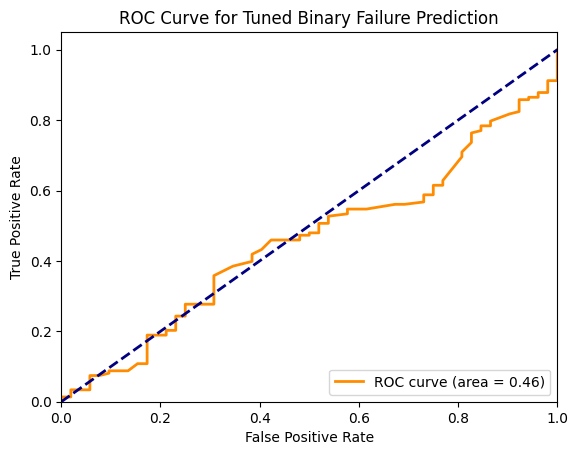

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# Define features (X) and the binary target (y)
X_new_binary = new_data_df_processed.drop('Binary_Failure', axis=1)
y_new_binary = new_data_df_processed['Binary_Failure']

# Drop rows with NaN values in features before splitting
# This handles the NaNs created by rolling features
data_for_training = pd.concat([X_new_binary, y_new_binary], axis=1).dropna()
X_new_binary_cleaned = data_for_training.drop('Binary_Failure', axis=1)
y_new_binary_cleaned = data_for_training['Binary_Failure']


# Split data into training and testing sets
X_train_new_binary, X_test_new_binary, y_train_new_binary, y_test_new_binary = train_test_split(
    X_new_binary_cleaned, y_new_binary_cleaned, test_size=0.2, random_state=42, stratify=y_new_binary_cleaned
)

# Instantiate a Gradient Boosting Classifier for binary classification
# model_2_binary = GradientBoostingClassifier(random_state=42) # Use the tuned model_2_binary
# model_2_binary.fit(X_train_new_binary, y_train_new_binary) # The model is already tuned

# Evaluate the tuned model_2_binary on the test data
y_pred_new_binary = model_2_binary.predict(X_test_new_binary)
y_proba_new_binary = model_2_binary.predict_proba(X_test_new_binary)[:, 1]

# Calculate and print classification metrics
accuracy_new_binary = accuracy_score(y_test_new_binary, y_pred_new_binary)
precision_new_binary = precision_score(y_test_new_binary, y_pred_new_binary)
recall_new_binary = recall_score(y_test_new_binary, y_pred_new_binary)
f1_new_binary = f1_score(y_test_new_binary, y_pred_new_binary)
conf_matrix_new_binary = confusion_matrix(y_test_new_binary, y_pred_new_binary)

print(f"Tuned Binary Classifier (Gradient Boosting) - Test Accuracy: {accuracy_new_binary:.4f}")
print(f"Tuned Binary Classifier (Gradient Boosting) - Test Precision: {precision_new_binary:.4f}")
print(f"Tuned Binary Classifier (Gradient Boosting) - Test Recall: {recall_new_binary:.4f}")
print(f"Tuned Binary Classifier (Gradient Boosting) - Test F1-score: {f1_new_binary:.4f}")
print("\nTuned Binary Classifier (Gradient Boosting) - Confusion Matrix:")
display(conf_matrix_new_binary)

# Plot ROC curve
fpr_new_binary, tpr_new_binary, thresholds_new_binary = roc_curve(y_test_new_binary, y_proba_new_binary)
roc_auc_new_binary = auc(fpr_new_binary, tpr_new_binary)

plt.figure()
plt.plot(fpr_new_binary, tpr_new_binary, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_new_binary:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Tuned Binary Failure Prediction')
plt.legend(loc="lower right")
plt.show()

In [3]:
# Re-run the data processing and binary target creation cells
# Load the data from the CSV file
import pandas as pd
new_data_df = pd.read_csv('/content/engine_failure_dataset.csv')

# Check for missing values
print("Missing values in the new dataset:")
display(new_data_df.isnull().sum())

# We don't have 'engine_id' or 'cycle' in this dataset, so we'll use existing columns as features.
# Let's select the numerical and categorical features.
numerical_features = ['Temperature (°C)', 'RPM', 'Fuel_Efficiency', 'Vibration_X', 'Vibration_Y', 'Vibration_Z', 'Torque', 'Power_Output (kW)']
categorical_features = ['Operational_Mode'] # 'Fault_Condition' will be our target

# Handle categorical features: One-Hot Encoding
new_data_df_processed = pd.get_dummies(new_data_df, columns=categorical_features, drop_first=True)

# We can also create some simple rolling features for the numerical columns
# Assuming 'Time_Stamp' is sorted correctly for rolling calculations
new_data_df_processed['Time_Stamp'] = pd.to_datetime(new_data_df_processed['Time_Stamp'])
new_data_df_processed = new_data_df_processed.sort_values(by='Time_Stamp')

window_size = 5
for col in numerical_features:
    new_data_df_processed[f'{col}_rolling_mean'] = new_data_df_processed[col].rolling(window=window_size, min_periods=1).mean()
    new_data_df_processed[f'{col}_rolling_std'] = new_data_df_processed[col].rolling(window=window_size, min_periods=1).std()

# Drop the original Time_Stamp column as it's no longer needed after sorting and potential feature engineering
new_data_df_processed = new_data_df_processed.drop('Time_Stamp', axis=1)

# Identify features for scaling (all numerical and one-hot encoded columns, excluding the target)
all_features = [col for col in new_data_df_processed.columns if col != 'Fault_Condition']

# Scale the features
from sklearn.preprocessing import StandardScaler
scaler_new = StandardScaler()
new_data_df_processed[all_features] = scaler_new.fit_transform(new_data_df_processed[all_features])

# Create a binary target variable: 1 if Fault_Condition is not 0, 0 otherwise
new_data_df_processed['Binary_Failure'] = (new_data_df_processed['Fault_Condition'] != 0).astype(int)

# Drop the original Fault_Condition column as we will use the binary target
new_data_df_processed = new_data_df_processed.drop('Fault_Condition', axis=1)

print("Data processing and binary target creation complete.")

Missing values in the new dataset:


,0
Time_Stamp,0
Temperature (°C),0
RPM,0
Fuel_Efficiency,0
Vibration_X,0
Vibration_Y,0
Vibration_Z,0
Torque,0
Power_Output (kW),0
Fault_Condition,0


Data processing and binary target creation complete.


### Adjusting Prediction Threshold for model_2_binary

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Assuming X_test_new_binary and y_test_new_binary are already defined
# Assuming model_2_binary (the tuned model) is already trained

# Get the predicted probabilities for the positive class (failure)
y_proba_tuned_binary = model_2_binary.predict_proba(X_test_new_binary)[:, 1]

# Define a range of thresholds to evaluate
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

print("Evaluating model performance at different prediction thresholds:")

for threshold in thresholds:
    # Predict class labels based on the current threshold
    y_pred_threshold = (y_proba_tuned_binary >= threshold).astype(int)

    # Calculate metrics
    precision_threshold = precision_score(y_test_new_binary, y_pred_threshold)
    recall_threshold = recall_score(y_test_new_binary, y_pred_threshold)
    f1_threshold = f1_score(y_test_new_binary, y_pred_threshold)
    conf_matrix_threshold = confusion_matrix(y_test_new_binary, y_pred_threshold)

    print(f"\n--- Threshold: {threshold:.2f} ---")
    print(f"  Precision: {precision_threshold:.4f}")
    print(f"  Recall: {recall_threshold:.4f}")
    print(f"  F1-score: {f1_threshold:.4f}")
    print("  Confusion Matrix:")
    display(conf_matrix_threshold)

Evaluating model performance at different prediction thresholds:

--- Threshold: 0.10 ---
  Precision: 0.7400
  Recall: 1.0000
  F1-score: 0.8506
  Confusion Matrix:


array([[  0,  52],
       [  0, 148]])


--- Threshold: 0.20 ---
  Precision: 0.7400
  Recall: 1.0000
  F1-score: 0.8506
  Confusion Matrix:


array([[  0,  52],
       [  0, 148]])


--- Threshold: 0.30 ---
  Precision: 0.7400
  Recall: 1.0000
  F1-score: 0.8506
  Confusion Matrix:


...


--- Threshold: 0.80 ---
  Precision: 1.0000
  Recall: 0.0068
  F1-score: 0.0134
  Confusion Matrix:


array([[ 52,   0],
       [147,   1]])


--- Threshold: 0.90 ---
  Precision: 0.0000
  Recall: 0.0000
  F1-score: 0.0000
  Confusion Matrix:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


array([[ 52,   0],
       [148,   0]])

Tuned Binary Classifier (Gradient Boosting) - Test Accuracy: 0.7400
Tuned Binary Classifier (Gradient Boosting) - Test Precision: 0.7400
Tuned Binary Classifier (Gradient Boosting) - Test Recall: 1.0000
Tuned Binary Classifier (Gradient Boosting) - Test F1-score: 0.8506

Tuned Binary Classifier (Gradient Boosting) - Confusion Matrix:


array([[  0,  52],
       [  0, 148]])

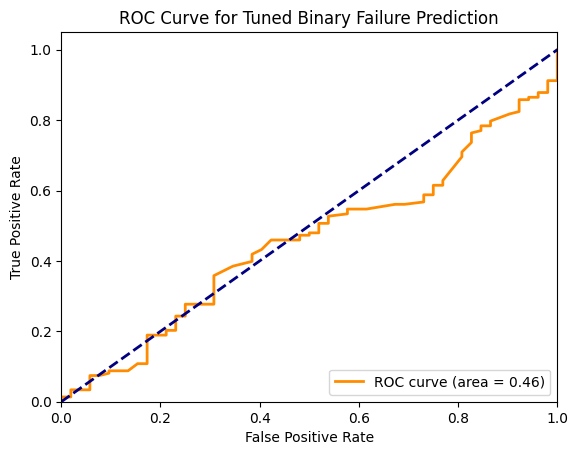

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# Define features (X) and the binary target (y)
X_new_binary = new_data_df_processed.drop('Binary_Failure', axis=1)
y_new_binary = new_data_df_processed['Binary_Failure']

# Drop rows with NaN values in features before splitting
# This handles the NaNs created by rolling features
data_for_training = pd.concat([X_new_binary, y_new_binary], axis=1).dropna()
X_new_binary_cleaned = data_for_training.drop('Binary_Failure', axis=1)
y_new_binary_cleaned = data_for_training['Binary_Failure']


# Split data into training and testing sets
X_train_new_binary, X_test_new_binary, y_train_new_binary, y_test_new_binary = train_test_split(
    X_new_binary_cleaned, y_new_binary_cleaned, test_size=0.2, random_state=42, stratify=y_new_binary_cleaned
)

# Instantiate a Gradient Boosting Classifier for binary classification
# model_2_binary = GradientBoostingClassifier(random_state=42) # Use the tuned model_2_binary
# model_2_binary.fit(X_train_new_binary, y_train_new_binary) # The model is already tuned

# Evaluate the tuned model_2_binary on the test data
y_pred_new_binary = model_2_binary.predict(X_test_new_binary)
y_proba_new_binary = model_2_binary.predict_proba(X_test_new_binary)[:, 1]

# Calculate and print classification metrics
accuracy_new_binary = accuracy_score(y_test_new_binary, y_pred_new_binary)
precision_new_binary = precision_score(y_test_new_binary, y_pred_new_binary)
recall_new_binary = recall_score(y_test_new_binary, y_pred_new_binary)
f1_new_binary = f1_score(y_test_new_binary, y_pred_new_binary)
conf_matrix_new_binary = confusion_matrix(y_test_new_binary, y_pred_new_binary)

print(f"Tuned Binary Classifier (Gradient Boosting) - Test Accuracy: {accuracy_new_binary:.4f}")
print(f"Tuned Binary Classifier (Gradient Boosting) - Test Precision: {precision_new_binary:.4f}")
print(f"Tuned Binary Classifier (Gradient Boosting) - Test Recall: {recall_new_binary:.4f}")
print(f"Tuned Binary Classifier (Gradient Boosting) - Test F1-score: {f1_new_binary:.4f}")
print("\nTuned Binary Classifier (Gradient Boosting) - Confusion Matrix:")
display(conf_matrix_new_binary)

# Plot ROC curve
fpr_new_binary, tpr_new_binary, thresholds_new_binary = roc_curve(y_test_new_binary, y_proba_new_binary)
roc_auc_new_binary = auc(fpr_new_binary, tpr_new_binary)

plt.figure()
plt.plot(fpr_new_binary, tpr_new_binary, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_new_binary:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Tuned Binary Failure Prediction')
plt.legend(loc="lower right")
plt.show()

### Hyperparameter Tuning for model_2_binary

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for GridSearchCV
param_grid_gbm_binary = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5]
}

# Assuming X_train_new_binary and y_train_new_binary are already defined and cleaned from previous steps.

# Initialize GridSearchCV with the binary model and parameter grid
grid_search_model_2_binary = GridSearchCV(estimator=model_2_binary, param_grid=param_grid_gbm_binary, cv=3, scoring='f1', n_jobs=-1)

# Perform GridSearchCV
grid_search_model_2_binary.fit(X_train_new_binary, y_train_new_binary)

# Get the best parameters and the best score
best_params_model_2_binary = grid_search_model_2_binary.best_params_
best_score_model_2_binary = grid_search_model_2_binary.best_score_

print(f"Best parameters for model_2_binary: {best_params_model_2_binary}")
print(f"Best F1-score on training data for model_2_binary: {best_score_model_2_binary:.4f}")

# Update model_2_binary with the best estimator
model_2_binary = grid_search_model_2_binary.best_estimator_

print("\nmodel_2_binary has been updated with the best parameters found by GridSearchCV.")

Best parameters for model_2_binary: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
Best F1-score on training data for model_2_binary: 0.8520

model_2_binary has been updated with the best parameters found by GridSearchCV.
